<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana12/Difusion_Perfil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

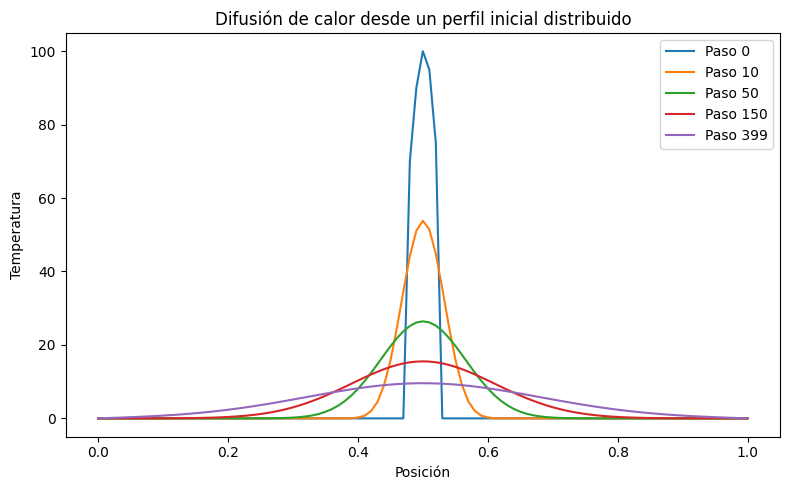

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# DIFUSION DE CALOR DESDE UN PERFIL INICIAL DISTRIBUIDO
# =====================================================

# Parametros del dominio
N = 101
L = 1.0
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Difusividad termica
alpha = 0.01

# Paso temporal (condicion de estabilidad)
dt = 0.4 * dx**2 / alpha

# Numero de pasos
steps = 400

# Perfil inicial arbitrario
T = np.zeros(N)
center = N // 2

T[center] = 100.0
T[center - 1] = 90.0
T[center + 1] = 95.0
T[center - 2] = 70.0
T[center + 2] = 75.0

# Guardar perfiles en distintos tiempos
snapshots = []
times_to_save = [0, 10, 50, 150, 399]

for n in range(steps):
    if n in times_to_save:
        snapshots.append((n, T.copy()))

    T_new = T.copy()

    # Bordes fijos
    T_new[0] = 0.0
    T_new[-1] = 0.0

    for i in range(1, N - 1):
        T_new[i] = T[i] + alpha * dt / dx**2 * (T[i + 1] - 2*T[i] + T[i - 1])

    T = T_new

# Guardar ultimo perfil si hace falta
if steps - 1 not in times_to_save:
    snapshots.append((steps - 1, T.copy()))

# Grafica
plt.figure(figsize=(8, 5))
for n, Ts in snapshots:
    plt.plot(x, Ts, label=f'Paso {n}')

plt.xlabel("Posición")
plt.ylabel("Temperatura")
plt.title("Difusión de calor desde un perfil inicial distribuido")
plt.legend()
plt.tight_layout()
plt.savefig("Difusion_Perfil.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Difusion_Perfil.pdf")